Upload your dataset...


Saving Telco Customer Churn.csv to Telco Customer Churn (2).csv

Best Iteration Found: 79
Final Test Accuracy: 0.8055


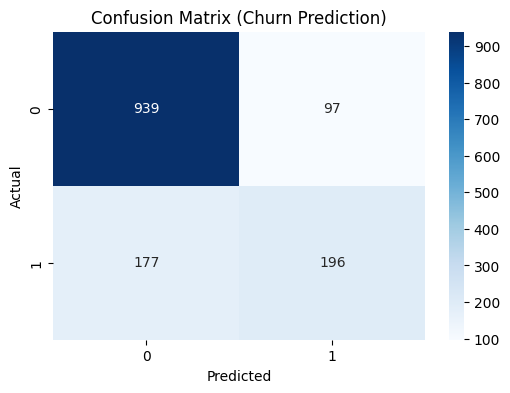

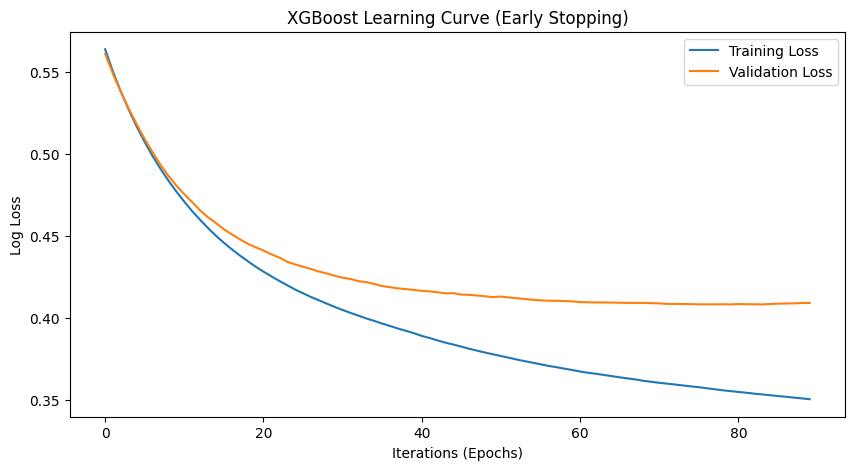


Model weights saved as: best_churn_model.json and model_weights.pkl


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io, pickle
from google.colab import files
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# --- 1. UPLOAD & PREPROCESS ---
print("Upload your dataset...")
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

if 'customerID' in df.columns: df.drop('customerID', axis=1, inplace=True)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
df['Churn'] = df['Churn'].apply(lambda x: 1 if str(x).lower() == 'yes' else 0)
X = pd.get_dummies(df.drop('Churn', axis=1), drop_first=True)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Validation set for Early Stopping
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=42)

# --- 2. THE FIX: MOVE EARLY STOPPING HERE ---
model = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    early_stopping_rounds=10, # <--- Fix: Moved from fit() to here
    eval_metric=["logloss"]
)

# Training without the problematic argument
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False
)

# --- 3. CONFUSION MATRIX & METRICS ---
preds = model.predict(X_test)
print(f"\nBest Iteration Found: {model.best_iteration}")
print(f"Final Test Accuracy: {accuracy_score(y_test, preds):.4f}")

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, preds), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Churn Prediction)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# --- 4. TRAINING HISTORY GRAPH (Loss Curve) ---
results = model.evals_result()
plt.figure(figsize=(10,5))
plt.plot(results['validation_0']['logloss'], label='Training Loss')
plt.plot(results['validation_1']['logloss'], label='Validation Loss')
plt.title('XGBoost Learning Curve (Early Stopping)')
plt.xlabel('Iterations (Epochs)')
plt.ylabel('Log Loss')
plt.legend()
plt.show()

# --- 5. SAVING MODEL WEIGHTS ---
# Saving as JSON (Standard for XGBoost)
model.save_model("best_churn_model.json")
# Saving as Pickle (Standard for Scikit-Learn)
with open('model_weights.pkl', 'wb') as f:
    pickle.dump(model, f)

print("\nModel weights saved as: best_churn_model.json and model_weights.pkl")